Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Upload long_silence.xlsx (original audio silence)


Saving corrected long silence.xlsx to corrected long silence.xlsx
Upload boundary_corrected.xlsx (translated syllable)


Saving boundary_corrected (2).xlsx to boundary_corrected (2).xlsx
Upload original audio


Saving english audio.mp3 to english audio.mp3
Upload translated audio


Saving new translateed.wav to new translateed.wav
Upload original video


Saving cropped video.mp4 to cropped video.mp4
Original Audio Duration: 28.824
Translated Audio Duration: 24.43


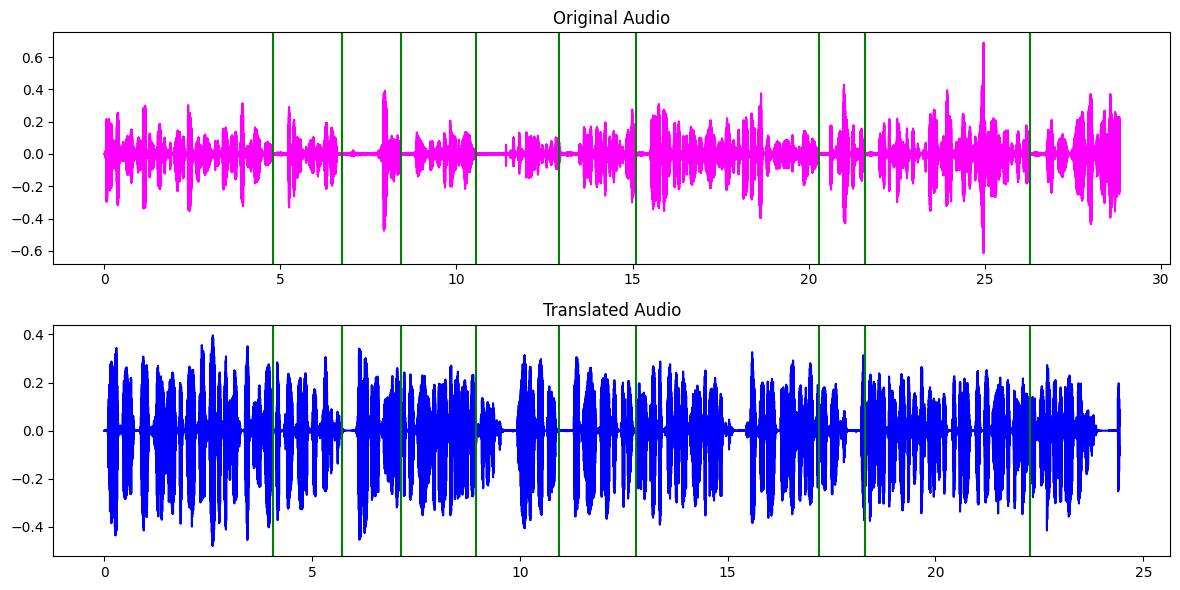

FFMPEG FILTER:
[0:v]trim=start=0.0:end=4.78,setpts=0.8475575908964751*(PTS-STARTPTS),drawtext=text='RESAMPLED':x=30:y=30:fontsize=36:fontcolor=red[v0];[0:v]trim=start=4.78:end=6.62,setpts=0.911236258431983*(PTS-STARTPTS),drawtext=text='RESAMPLED':x=30:y=30:fontsize=36:fontcolor=red[v1];[0:v]trim=start=6.62:end=7.09,setpts=0.0*(PTS-STARTPTS),drawtext=text='RESAMPLED':x=30:y=30:fontsize=36:fontcolor=red[v2];[0:v]trim=start=7.09:end=8.43,setpts=1.0573958889979735*(PTS-STARTPTS),drawtext=text='RESAMPLED':x=30:y=30:fontsize=36:fontcolor=red[v3];[0:v]trim=start=8.43:end=10.56,setpts=0.8475575908964755*(PTS-STARTPTS),drawtext=text='RESAMPLED':x=30:y=30:fontsize=36:fontcolor=red[v4];[0:v]trim=start=10.56:end=12.96,setpts=0.8307466000555096*(PTS-STARTPTS),drawtext=text='RESAMPLED':x=30:y=30:fontsize=36:fontcolor=red[v5];[0:v]trim=start=12.96:end=15.11,setpts=0.8663233481142968*(PTS-STARTPTS),drawtext=text='RESAMPLED':x=30:y=30:fontsize=36:fontcolor=red[v6];[0:v]trim=start=15.11:end=20.28,setpts

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!apt-get install ffmpeg -y

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from google.colab import files
import subprocess

# -----------------------------
# Upload files
# -----------------------------

print("Upload long_silence.xlsx (original audio silence)")
uploaded = files.upload()
long_file=list(uploaded.keys())[0]

print("Upload boundary_corrected.xlsx (translated syllable)")
uploaded = files.upload()
boundary_file=list(uploaded.keys())[0]

print("Upload original audio")
uploaded = files.upload()
orig_audio=list(uploaded.keys())[0]

print("Upload translated audio")
uploaded = files.upload()
trans_audio=list(uploaded.keys())[0]

print("Upload original video")
uploaded = files.upload()
video_file=list(uploaded.keys())[0]

# -----------------------------
# Load audio
# -----------------------------

y1,sr1 = librosa.load(orig_audio,sr=None)
y2,sr2 = librosa.load(trans_audio,sr=None)

orig_audio_dur=len(y1)/sr1
trans_audio_dur=len(y2)/sr2

print("Original Audio Duration:",orig_audio_dur)
print("Translated Audio Duration:",trans_audio_dur)

# -----------------------------
# Load silence + syllable
# -----------------------------

sil=pd.read_excel(long_file)
syll=pd.read_excel(boundary_file)

sil_points=sil["Start"].values
syll_points=syll["Start"].values

# -----------------------------
# Map anchors using formula
# -----------------------------

mapped=[]

for s in sil_points:
    m=(s/orig_audio_dur)*trans_audio_dur
    mapped.append(m)

mapped=np.array(mapped)

# -----------------------------
# Snap anchors to nearest syllable
# -----------------------------

snapped=[]

for m in mapped:

    diff=np.abs(syll_points-m)
    idx=np.argmin(diff)

    if diff[idx] <= 0.3:
        snapped.append(syll_points[idx])
    else:
        snapped.append(m)

snapped=np.array(snapped)

# -----------------------------
# Map anchors back to video
# -----------------------------

video_anchors=(snapped/trans_audio_dur)*orig_audio_dur

# -----------------------------
# Add start/end anchors
# -----------------------------

orig_points=np.concatenate(([0],sil_points,[orig_audio_dur]))
trans_points=np.concatenate(([0],snapped,[trans_audio_dur]))

# -----------------------------
# Compute stretch factors
# -----------------------------

stretch=[]

for i in range(len(orig_points)-1):

    o_len=orig_points[i+1]-orig_points[i]
    t_len=trans_points[i+1]-trans_points[i]

    factor=t_len/o_len
    stretch.append(factor)

# -----------------------------
# Save mapping
# -----------------------------

mapping=pd.DataFrame({
"Original_anchor":orig_points,
"Translated_anchor":trans_points
})

mapping.to_excel("anchor_mapping.xlsx",index=False)

# -----------------------------
# Plot waveforms
# -----------------------------

t1=np.arange(len(y1))/sr1
t2=np.arange(len(y2))/sr2

plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plt.plot(t1,y1,color="magenta")
for v in video_anchors:
    plt.axvline(v,color="green")
plt.title("Original Audio")

plt.subplot(2,1,2)
plt.plot(t2,y2,color="blue")
for s in snapped:
    plt.axvline(s,color="green")
plt.title("Translated Audio")

plt.tight_layout()
plt.savefig("alignment_plot.png")
plt.show()

# -----------------------------
# Build ffmpeg filter
# -----------------------------

filters=[]
streams=[]

for i in range(len(orig_points)-1):

    start=orig_points[i]
    end=orig_points[i+1]
    factor=stretch[i]

    filters.append(
        f"[0:v]trim=start={start}:end={end},"
        f"setpts={factor}*(PTS-STARTPTS),"
        f"drawtext=text='RESAMPLED':x=30:y=30:fontsize=36:fontcolor=red[v{i}];"
    )

    streams.append(f"[v{i}]")

filter_complex="".join(filters)+ "".join(streams) + f"concat=n={len(streams)}:v=1:a=0[outv]"

print("FFMPEG FILTER:")
print(filter_complex)

# -----------------------------
# Stretch video
# -----------------------------

subprocess.run([
"ffmpeg",
"-y",
"-i",video_file,
"-filter_complex",filter_complex,
"-map","[outv]",
"-an",
"video_stretched.mp4"
])

# -----------------------------
# Attach translated audio
# -----------------------------

subprocess.run([
"ffmpeg",
"-y",
"-i","video_stretched.mp4",
"-i",trans_audio,
"-map","0:v",
"-map","1:a",
"-shortest",
"final_lipsync_video.mp4"
])

# -----------------------------
# Print durations
# -----------------------------

print("\nChecking video duration...")

subprocess.run([
"ffprobe",
"-i","final_lipsync_video.mp4",
"-show_entries","format=duration",
"-v","quiet",
"-of","csv=p=0"
])

# -----------------------------
# Download outputs
# -----------------------------

files.download("final_lipsync_video.mp4")
files.download("alignment_plot.png")
files.download("anchor_mapping.xlsx")

In [ ]:
# =============================
# INSTALL
# =============================
!apt-get install ffmpeg -y
!pip install openai-whisper

# =============================
# IMPORTS
# =============================
import numpy as np
import pandas as pd
import librosa
import os
import subprocess
from google.colab import files
import whisper

# =============================
# UPLOAD FILES
# =============================

print("Upload long_silence.xlsx")
uploaded = files.upload()
long_file=list(uploaded.keys())[0]

print("Upload original audio")
uploaded = files.upload()
orig_audio=list(uploaded.keys())[0]

print("Upload translated audio")
uploaded = files.upload()
trans_audio=list(uploaded.keys())[0]

print("Upload original video")
uploaded = files.upload()
video_file=list(uploaded.keys())[0]

# =============================
# LOAD AUDIO
# =============================

y1,sr1 = librosa.load(orig_audio,sr=None)
y2,sr2 = librosa.load(trans_audio,sr=None)

orig_dur = len(y1)/sr1
trans_dur = len(y2)/sr2

print("Original Duration:", orig_dur)
print("Translated Duration:", trans_dur)

# =============================
# LOAD SILENCE
# =============================

sil = pd.read_excel(long_file)
sil_points = sil["Start"].values

# =============================
# WORD TIMESTAMPS USING WHISPER
# =============================

model = whisper.load_model("base")
result = model.transcribe(trans_audio, word_timestamps=True)

words = []
for seg in result["segments"]:
    for w in seg["words"]:
        words.append(w["start"])

word_points = np.array(words)

# =============================
# HYBRID ANCHORS (SILENCE + WORD)
# =============================

anchors = np.sort(np.concatenate((sil_points, word_points)))

# map anchors to translated timeline
mapped = (anchors / orig_dur) * trans_dur

orig_pts = np.concatenate(([0], anchors, [orig_dur]))
trans_pts = np.concatenate(([0], mapped, [trans_dur]))

# =============================
# GET FPS
# =============================

fps = float(subprocess.check_output([
    "ffprobe","-v","0",
    "-of","csv=p=0",
    "-select_streams","v:0",
    "-show_entries","stream=r_frame_rate",
    video_file
]).decode().strip().split('/')[0])

print("FPS:", fps)

# =============================
# EXTRACT FRAMES
# =============================

os.makedirs("frames", exist_ok=True)

subprocess.run([
    "ffmpeg","-y",
    "-i",video_file,
    "frames/frame_%05d.png"
])

# =============================
# BUILD NEW FRAME SEQUENCE
# =============================

new_sequence = []
current_frame = 1

for i in range(len(orig_pts)-1):

    o_len = orig_pts[i+1] - orig_pts[i]
    t_len = trans_pts[i+1] - trans_pts[i]

    o_frames = int(o_len * fps)
    t_frames = int(t_len * fps)

    if o_frames <= 1:
        continue

    indices = np.linspace(0, o_frames-1, t_frames).astype(int)

    for idx in indices:
        new_sequence.append(current_frame + idx)

    current_frame += o_frames

print("New frame count:", len(new_sequence))

# =============================
# CREATE RETIMED FRAMES
# =============================

os.makedirs("retimed_frames", exist_ok=True)

for i, f in enumerate(new_sequence):
    src = f"frames/frame_{str(f).zfill(5)}.png"
    dst = f"retimed_frames/frame_{str(i+1).zfill(5)}.png"

    if os.path.exists(src):
        os.system(f"cp {src} {dst}")

# =============================
# CREATE VIDEO FROM FRAMES
# =============================

subprocess.run([
    "ffmpeg","-y",
    "-framerate", str(fps),
    "-i","retimed_frames/frame_%05d.png",
    "-c:v","libx264",
    "-pix_fmt","yuv420p",
    "video_retimed.mp4"
])

# =============================
# MOTION EXTENSION (NO AI MODEL)
# =============================

subprocess.run([
    "ffmpeg","-y",
    "-i","video_retimed.mp4",
    "-vf","minterpolate=fps=60:mi_mode=mci",
    "video_smooth.mp4"
])

# =============================
# MATCH EXACT DURATION
# =============================

subprocess.run([
    "ffmpeg","-y",
    "-i","video_smooth.mp4",
    "-t", str(trans_dur),
    "-c","copy",
    "video_final.mp4"
])

# =============================
# ADD TRANSLATED AUDIO
# =============================

subprocess.run([
    "ffmpeg","-y",
    "-i","video_final.mp4",
    "-i",trans_audio,
    "-map","0:v",
    "-map","1:a",
    "-shortest",
    "final_output.mp4"
])

# =============================
# DOWNLOAD OUTPUT
# =============================

files.download("final_output.mp4")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 11.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 6.7 MB/s eta 0:00:00
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=445a8d6ee7a73a33be4b6f3c09415258dfe0900dcf2440158cfcc17a24d7b146
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper
Upload long_silence.xlsx


Saving corrected long silence.xlsx to corrected long silence (1).xlsx
Upload original audio


Saving english audio.mp3 to english audio (1).mp3
Upload translated audio


Saving new translateed.wav to new translateed (1).wav
Upload original video


Saving cropped video.mp4 to cropped video (1).mp4
Original Duration: 28.824
Translated Duration: 24.43


100%|████████████████████████████████████████| 139M/139M [00:01<00:00, 110MiB/s]
/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


FPS: 30.0
New frame count: 698


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>